In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os, cv2, numpy as np
import tensorflow as tf
from tensorflow.keras import models

BASE = "/content/drive/MyDrive/coco20k"
TRAIN_IMG  = f"{BASE}/train/images"
TRAIN_MASK = f"{BASE}/train/masks"
VAL_IMG    = f"{BASE}/val/images"
VAL_MASK   = f"{BASE}/val/masks"

IMG_SIZE = 128
BATCH = 16

def get_pairs(img_dir, mask_dir):
    imgs = sorted(os.listdir(img_dir))
    paired = []
    for img in imgs:
        mask = img.replace('.jpg','.png')
        if os.path.exists(os.path.join(mask_dir, mask)):
            paired.append(img)
    return paired

val_files = get_pairs(VAL_IMG, VAL_MASK)[:50]

def load_matched(img_dir, mask_dir, files):
    X, Y = [], []
    for f in files:
        img = cv2.imread(os.path.join(img_dir,f))
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))/255.0
        mask = cv2.imread(os.path.join(mask_dir,f.replace(".jpg",".png")),0)
        mask = cv2.resize(mask,(IMG_SIZE,IMG_SIZE))/255.0
        X.append(img)
        Y.append(mask[...,None])
    return np.array(X), np.array(Y)

valX, valY = load_matched(VAL_IMG, VAL_MASK, val_files)

model = models.load_model("/content/drive/MyDrive/unet_task4_final.h5",
                          custom_objects={
                              "dice_coef": lambda y_true, y_pred: 0,
                              "iou_metric": lambda y_true, y_pred: 0
                          })


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Val Loss: 0.6140701174736023
Val Accuracy: 0.6701159477233887
Val Dice: 0.0
Val IoU: 0.0


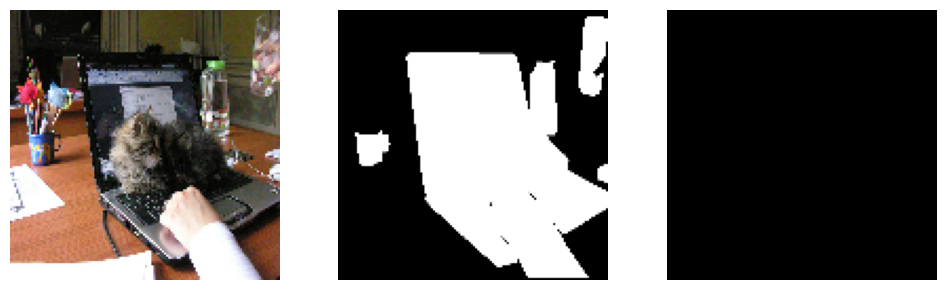

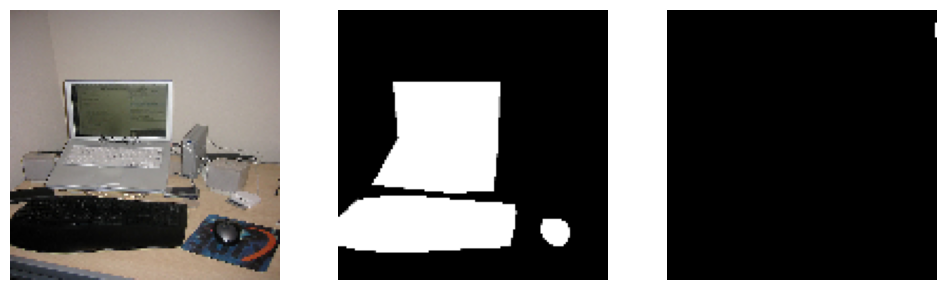

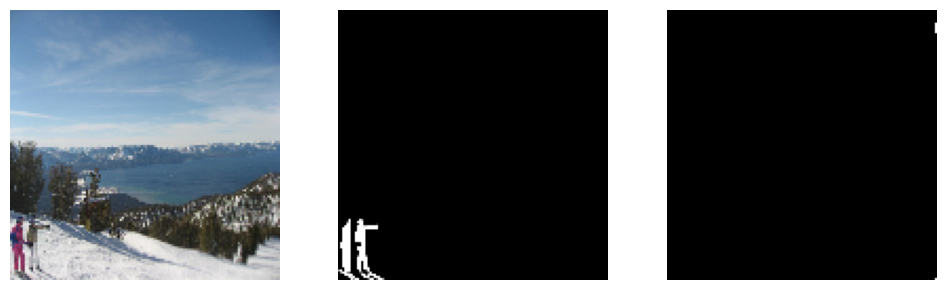

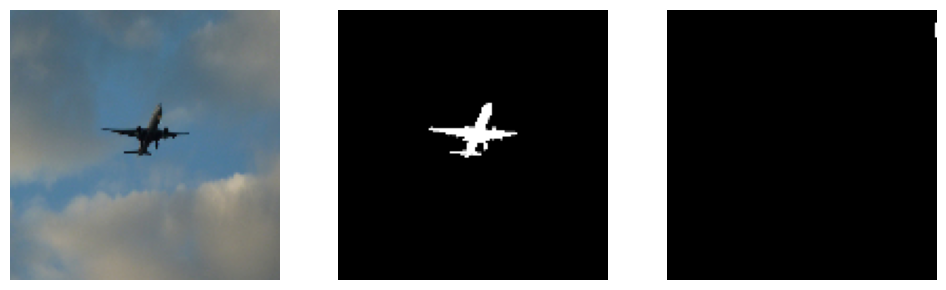

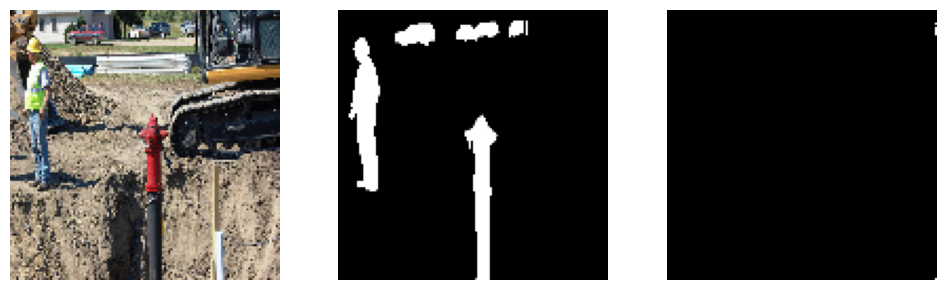

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import os

results = model.evaluate(valX, valY, batch_size=BATCH, verbose=0)
print("Val Loss:", results[0])
print("Val Accuracy:", results[1])
print("Val Dice:", results[2])
print("Val IoU:", results[3])

OUT_DIR = f"{BASE}/task5_predictions"
os.makedirs(OUT_DIR, exist_ok=True)

indices = list(range(min(5, len(valX))))

for idx in indices:
    img = valX[idx]
    gt = valY[idx][:,:,0]
    pred = model.predict(np.expand_dims(img, 0), verbose=0)[0,:,:,0]
    pred_bin = (pred > 0.5).astype(np.float32)

    fig = plt.figure(figsize=(10,3))
    ax1 = fig.add_subplot(1,3,1)
    ax1.imshow(img)
    ax1.axis("off")

    ax2 = fig.add_subplot(1,3,2)
    ax2.imshow(gt, cmap="gray")
    ax2.axis("off")

    ax3 = fig.add_subplot(1,3,3)
    ax3.imshow(pred_bin, cmap="gray")
    ax3.axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"val_sample_{idx}.png"))
    plt.show()
